### THIS FILE WAS PROVIDED BY MY PI FOR USEFUL REFERENCE CODE IN REGARDS TO COMBINING THE SPECTRA

Could do to improve spectra:
* Re-extract with better centering

In [ ]:
from astropy.io import fits
import specutils
from specutils import Spectrum1D, SpectrumList
from specutils.manipulation import FluxConservingResampler, median_smooth
import glob
import numpy as np
from matplotlib import pyplot as plt
from utilities_az import visualization as viz
import astropy.units as u
import json
from astropy.time import Time

In [2]:
%matplotlib notebook

In [3]:
new_spectral_axis = np.concatenate([np.arange(1667, 3040, 1.37), #G230LB
                                    np.arange(3040, 5615, 2.75), #G430L
                                    np.arange(5615, 10250, 4.87)])* u.angstrom #G750L
resampler = FluxConservingResampler(extrapolation_treatment='nan_fill')

In [4]:
colors = viz.make_color_wheel(16, cmap='Spectral')

# Visit 1

### First two exposures are blank

In [5]:
def prepare_spectrum_v1(filename,  new_spectral_axis, scale_spectrum=None):
    opt_elem = fits.getval(filename, 'OPT_ELEM', 0)
    tbdata = fits.getdata(filename, 1)
    good_indx = ((tbdata['DQ']&16!=16) & (tbdata['DQ']&512!=512))
    spec = specutils.hst_stis.Spectrum1D(spectral_axis=tbdata['WAVELENGTH'][good_indx]*u.angstrom, flux=tbdata['FLUX'][good_indx]*u.erg/u.cm**2/u.s/u.angstrom)
    if opt_elem == 'G750L':
        spec = resampler(spec, u.angstrom*np.arange(spec.spectral_axis.value.max(), 5400, -np.diff(spec.spectral_axis.value)[0])[::-1])

    if opt_elem == 'G430L':
        spec = resampler(spec, u.angstrom*np.arange(spec.spectral_axis.value.max(), 3040, -np.diff(spec.spectral_axis.value)[0])[::-1])

    if opt_elem == 'G230LB':
        spec = resampler(spec, u.angstrom*np.arange(spec.spectral_axis.value.min(), 3050, np.diff(spec.spectral_axis.value)[0]))
    
    new_spec = resampler(spec, new_spectral_axis)
    if scale_spectrum:
        ratio = median_smooth(new_spec, width=5).flux.value/median_smooth(scale_spectrum, width=5).flux.value
        nan_indx = np.isnan(ratio)
        fit_params = np.polyfit(new_spectral_axis.value[~nan_indx][400:800],ratio[~nan_indx][400:800] , 1)
        scale = np.polyval(fit_params, new_spectral_axis.value)
        new_spec = new_spec/scale
    return new_spec

In [6]:
def plot_saturated(filename, ax, ymax, ymin=0, color='k'):
    tbdata = fits.getdata(filename, 1)
    saturated_indx = tbdata['DQ']&256 == 256
    saturated_wavelengths = tbdata['WAVELENGTH'][saturated_indx]
    ax.vlines(saturated_wavelengths, ymin=ymin, ymax=ymax, alpha=0.05, color=color, zorder=0)
    return 


In [67]:
flist_v1 = glob.glob('../data/spectra/HST/oezt01*x1d.fits')
flist_v1.sort()
flist_v1
flist_v1[-3] = flist_v1[-3].replace('x1d', 'dsx1')
flist_v1[-4] = flist_v1[-4].replace('x1d', 'dsx1')
flist_v1

['../data/spectra/HST/oezt01010_x1d.fits',
 '../data/spectra/HST/oezt01020_x1d.fits',
 '../data/spectra/HST/oezt01030_x1d.fits',
 '../data/spectra/HST/oezt01040_x1d.fits',
 '../data/spectra/HST/oezt01050_x1d.fits',
 '../data/spectra/HST/oezt01060_x1d.fits',
 '../data/spectra/HST/oezt01070_x1d.fits',
 '../data/spectra/HST/oezt01080_x1d.fits',
 '../data/spectra/HST/oezt01090_x1d.fits',
 '../data/spectra/HST/oezt010a0_x1d.fits',
 '../data/spectra/HST/oezt010b0_x1d.fits',
 '../data/spectra/HST/oezt010c0_x1d.fits',
 '../data/spectra/HST/oezt010e0_dsx1.fits',
 '../data/spectra/HST/oezt010f0_dsx1.fits',
 '../data/spectra/HST/oezt010g0_x1d.fits',
 '../data/spectra/HST/oezt010h0_x1d.fits']

In [68]:
# There are slit losses from the object saturating the acqusition images. 
# Exposure 12 has the highest flux and seems to match the optical spectra as well
spec12 = prepare_spectrum_v1(flist_v1[11], new_spectral_axis)

In [69]:
spec3 =  prepare_spectrum_v1(flist_v1[2], new_spectral_axis, scale_spectrum=spec12)
spec4 =  prepare_spectrum_v1(flist_v1[3], new_spectral_axis, scale_spectrum=spec12)
spec5 =  prepare_spectrum_v1(flist_v1[4], new_spectral_axis, scale_spectrum=spec12)
spec6 =  prepare_spectrum_v1(flist_v1[5], new_spectral_axis, scale_spectrum=spec12)
spec7 =  prepare_spectrum_v1(flist_v1[6], new_spectral_axis, scale_spectrum=spec12)
spec8 =  prepare_spectrum_v1(flist_v1[7], new_spectral_axis, scale_spectrum=spec12)
spec9 =  prepare_spectrum_v1(flist_v1[8], new_spectral_axis, scale_spectrum=spec12)
spec10 = prepare_spectrum_v1(flist_v1[9], new_spectral_axis, scale_spectrum=spec12)
spec11 = prepare_spectrum_v1(flist_v1[10], new_spectral_axis, scale_spectrum=spec12)
#spec12 = prepare_spectrum(flist_v1[11], new_spectral_axis, scale_spectrum=spec12)
spec14 = prepare_spectrum_v1(flist_v1[13], new_spectral_axis)
spec13 = prepare_spectrum_v1(flist_v1[12], new_spectral_axis, scale_spectrum=spec14)
spec16 = prepare_spectrum_v1(flist_v1[15], new_spectral_axis)
spec15 = prepare_spectrum_v1(flist_v1[14], new_spectral_axis, scale_spectrum=spec16)


/var/folders/6l/54htg8p52b762n_6mhsb13v80000gn/T/ipykernel_32082/2707404829.py:17: RuntimeWarning: invalid value encountered in divide
  ratio = median_smooth(new_spec, width=5).flux.value/median_smooth(scale_spectrum, width=5).flux.value


In [70]:
combined_flux_v1 = np.nanmedian(np.vstack([spec3.flux.value, spec4.flux.value, spec5.flux.value,  
                                            spec6.flux.value, spec7.flux.value, spec8.flux.value,
                                            spec9.flux.value, spec10.flux.value, spec11.flux.value,
                                            spec12.flux.value, 
                                            spec13.flux.value*1.9, 
                                            spec14.flux.value*1.9, 
                                            spec15.flux.value*1.09, 
                                            spec16.flux.value*1.09]), 
                                axis=0)*u.erg/u.cm**2/u.s/u.angstrom
combined_spectrum_v1 = Spectrum1D(spectral_axis=new_spectral_axis, flux=combined_flux_v1)

<IPython.core.display.Javascript object>


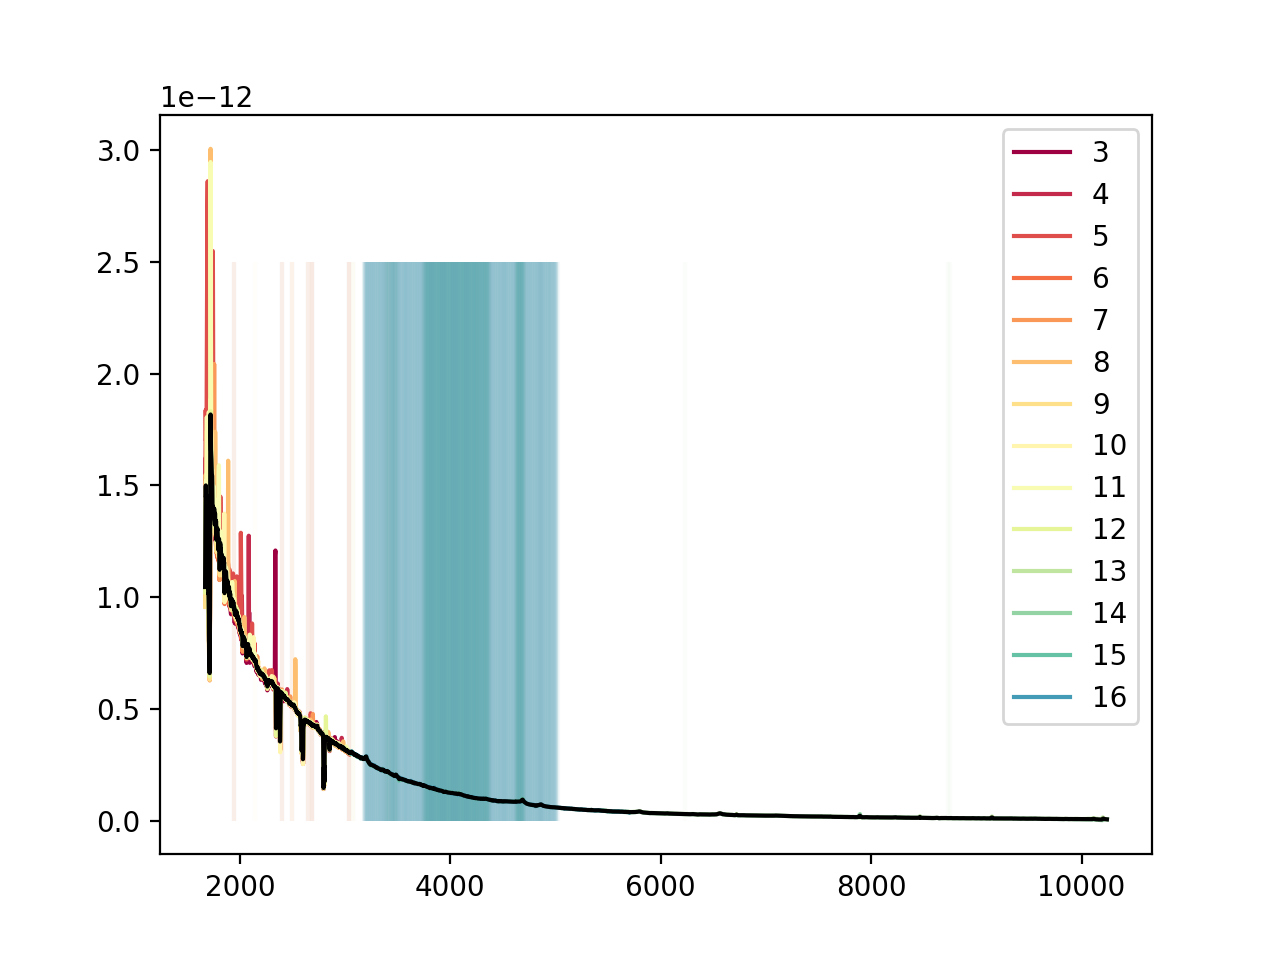

In [71]:
f, ax = plt.subplots()
ax.plot(spec3.spectral_axis, spec3.flux, label='3', color=colors[0])
ax.plot(spec4.spectral_axis, spec4.flux, label='4', color=colors[1])
ax.plot(spec5.spectral_axis, spec5.flux, label='5', color=colors[2])
ax.plot(spec6.spectral_axis, spec6.flux, label='6', color=colors[3])
ax.plot(spec7.spectral_axis, spec7.flux, label='7', color=colors[4])
ax.plot(spec8.spectral_axis, spec8.flux, label='8', color=colors[5])
ax.plot(spec9.spectral_axis, spec9.flux, label='9', color=colors[6])
ax.plot(spec10.spectral_axis, spec10.flux, label='10', color=colors[7])
ax.plot(spec11.spectral_axis, spec11.flux, label='11', color=colors[8])
ax.plot(spec12.spectral_axis, spec12.flux, label='12', color=colors[9])
ax.plot(spec13.spectral_axis, spec13.flux*1.9, label='13', color=colors[10])
ax.plot(spec14.spectral_axis, spec14.flux*1.9, label='14', color=colors[11])
ax.plot(spec15.spectral_axis, spec15.flux*1.09, label='15', color=colors[12])
ax.plot(spec16.spectral_axis, spec16.flux*1.09, label='16', color=colors[13])
ax.plot(combined_spectrum_v1.spectral_axis, combined_spectrum_v1.flux, color='k')
plt.legend()
for indx, (ifile, color) in enumerate(zip(flist_v1[2:], colors)):
    if indx>=14:
        continue
    plot_saturated(ifile, ax, ymax=2.5E-12, color=color)

# Visit 2

In [72]:
def prepare_spectrum_v2(filename,  new_spectral_axis, scale_spectrum=None):
    opt_elem = fits.getval(filename, 'OPT_ELEM', 0)
    tbdata = fits.getdata(filename, 1)
    good_indx = ((tbdata['DQ']&16!=16) & (tbdata['DQ']&512!=512))
    spec = specutils.hst_stis.Spectrum1D(spectral_axis=tbdata['WAVELENGTH'][good_indx]*u.angstrom, flux=tbdata['FLUX'][good_indx]*u.erg/u.cm**2/u.s/u.angstrom)
    if opt_elem == 'G750L':
        spec = resampler(spec, u.angstrom*np.arange(spec.spectral_axis.value.max(), 5400, -np.diff(spec.spectral_axis.value)[0])[::-1])

    if opt_elem == 'G430L':
        spec = resampler(spec, u.angstrom*np.arange(spec.spectral_axis.value.max(), 3040, -np.diff(spec.spectral_axis.value)[0])[::-1])

    if opt_elem == 'G230LB':
        spec = resampler(spec, u.angstrom*np.arange(spec.spectral_axis.value.min(), 3050, np.diff(spec.spectral_axis.value)[0]))
    
    new_spec = resampler(spec, new_spectral_axis)
    if scale_spectrum:
        ratio = median_smooth(new_spec, width=5).flux.value/median_smooth(scale_spectrum, width=5).flux.value
        nan_indx = np.isnan(ratio)
        fit_params = np.polyfit(new_spectral_axis.value[~nan_indx][100:900],ratio[~nan_indx][100:900] , 1)
        scale = np.polyval(fit_params, new_spectral_axis.value)
        new_spec = new_spec/scale
    return new_spec

In [73]:
flist_v2 = glob.glob('../data/spectra/HST/oezt02*x1d.fits')
flist_v2.sort()
flist_v2[-3] = flist_v2[-3].replace('x1d', 'dsx1')
flist_v2[-4] = flist_v2[-4].replace('x1d', 'dsx1')

In [74]:
# There are slit losses from the object saturating the acqusition images. 
# Exposure 12 has the highest flux and seems to match the optical spectra as well
spec4_v2 = prepare_spectrum_v2(flist_v2[3], new_spectral_axis)

In [75]:
spec1_v2 =  prepare_spectrum_v2(flist_v2[0], new_spectral_axis, scale_spectrum=spec4_v2)
spec2_v2 =  prepare_spectrum_v2(flist_v2[1], new_spectral_axis, scale_spectrum=spec4_v2)
spec3_v2 =  prepare_spectrum_v2(flist_v2[2], new_spectral_axis, scale_spectrum=spec4_v2)
#spec4_v2 =  prepare_spectrum_v2(flist_v2[3], new_spectral_axis)
spec5_v2 =  prepare_spectrum_v2(flist_v2[4], new_spectral_axis, scale_spectrum=spec4_v2)
spec6_v2 =  prepare_spectrum_v2(flist_v2[5], new_spectral_axis, scale_spectrum=spec4_v2)
spec7_v2 =  prepare_spectrum_v2(flist_v2[6], new_spectral_axis, scale_spectrum=spec4_v2)
spec8_v2 =  prepare_spectrum_v2(flist_v2[7], new_spectral_axis, scale_spectrum=spec4_v2)
spec9_v2 =  prepare_spectrum_v2(flist_v2[8], new_spectral_axis, scale_spectrum=spec4_v2)
spec10_v2 = prepare_spectrum_v2(flist_v2[9], new_spectral_axis, scale_spectrum=spec4_v2)
spec11_v2 = prepare_spectrum_v2(flist_v2[10], new_spectral_axis, scale_spectrum = spec4_v2)
spec12_v2 = prepare_spectrum_v2(flist_v2[11], new_spectral_axis, scale_spectrum = spec4_v2)
spec14_v2 = prepare_spectrum_v2(flist_v2[13], new_spectral_axis)
spec13_v2 = prepare_spectrum_v2(flist_v2[12], new_spectral_axis)
spec16_v2 = prepare_spectrum_v2(flist_v2[15], new_spectral_axis)
spec15_v2 = prepare_spectrum_v2(flist_v2[14], new_spectral_axis, scale_spectrum=spec16_v2)

/var/folders/6l/54htg8p52b762n_6mhsb13v80000gn/T/ipykernel_32082/3763175262.py:17: RuntimeWarning: invalid value encountered in divide
  ratio = median_smooth(new_spec, width=5).flux.value/median_smooth(scale_spectrum, width=5).flux.value


In [76]:
combined_flux_v2 = np.nanmedian(np.vstack([spec1_v2.flux.value, spec2_v2.flux.value,
                                            spec3_v2.flux.value, spec4_v2.flux.value, spec5_v2.flux.value,  
                                            spec6_v2.flux.value, spec7_v2.flux.value, spec8_v2.flux.value,
                                            spec9_v2.flux.value, spec10_v2.flux.value, spec11_v2.flux.value,
                                            spec12_v2.flux.value, 
                                            spec13_v2.flux.value, 
                                            spec14_v2.flux.value, 
                                            spec15_v2.flux.value, 
                                            spec16_v2.flux.value]), 
                                axis=0)*u.erg/u.cm**2/u.s/u.angstrom
combined_spectrum_v2 = Spectrum1D(spectral_axis=new_spectral_axis, flux=combined_flux_v2)

<IPython.core.display.Javascript object>


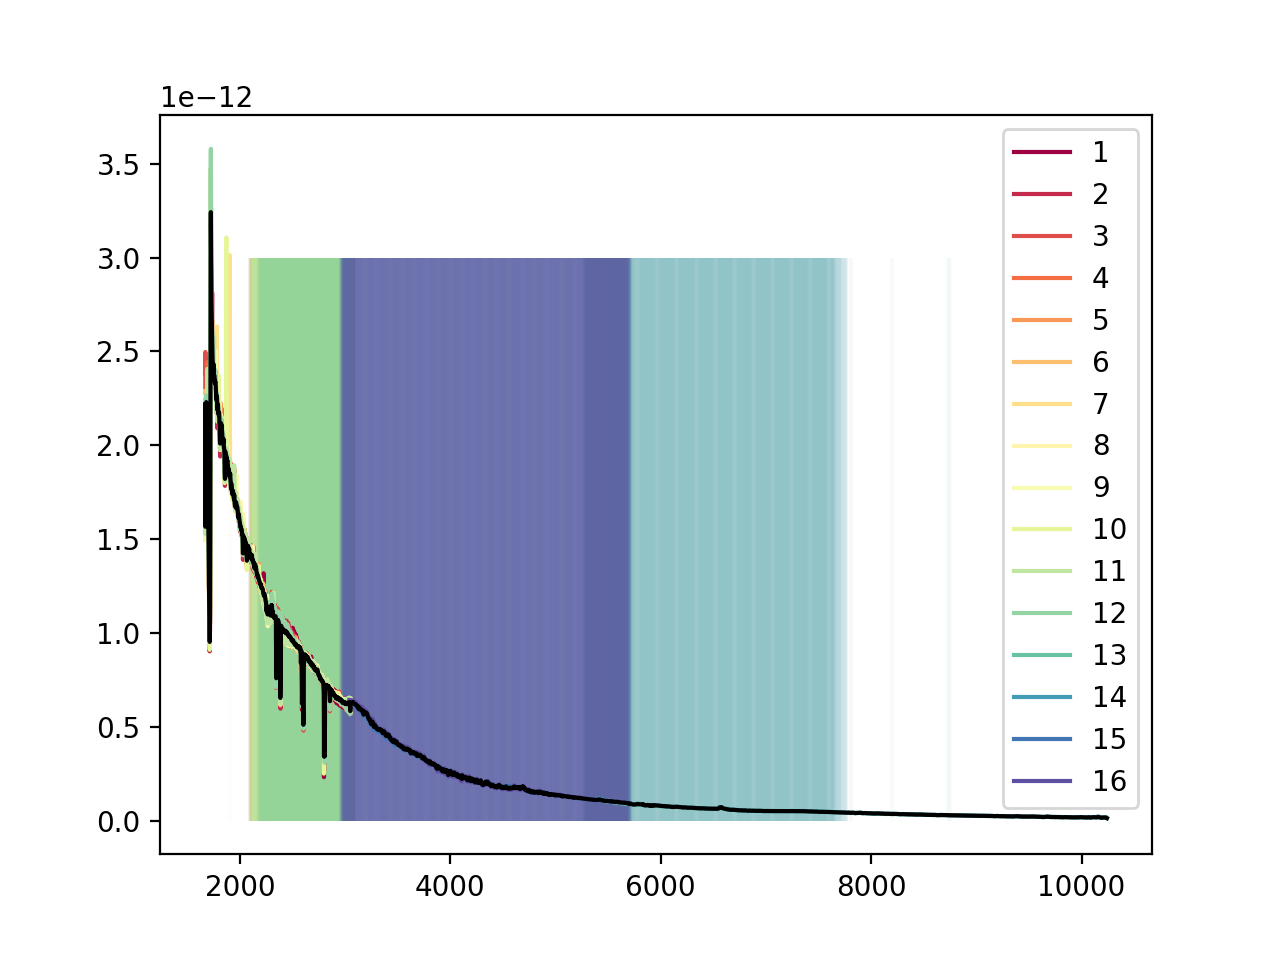

In [77]:
f, ax = plt.subplots()
ax.plot(spec1_v2.spectral_axis, spec1_v2.flux, label='1', color=colors[0])
ax.plot(spec2_v2.spectral_axis, spec2_v2.flux, label='2', color=colors[1])
ax.plot(spec3_v2.spectral_axis, spec3_v2.flux, label='3', color=colors[2])
ax.plot(spec4_v2.spectral_axis, spec4_v2.flux, label='4', color=colors[3])
ax.plot(spec5_v2.spectral_axis, spec5_v2.flux, label='5', color=colors[4])
ax.plot(spec6_v2.spectral_axis, spec6_v2.flux, label='6', color=colors[5])
ax.plot(spec7_v2.spectral_axis, spec7_v2.flux, label='7', color=colors[6])
ax.plot(spec8_v2.spectral_axis, spec8_v2.flux, label='8', color=colors[7])
ax.plot(spec9_v2.spectral_axis, spec9_v2.flux, label='9', color=colors[8])
ax.plot(spec10_v2.spectral_axis, spec10_v2.flux, label='10', color=colors[9])
ax.plot(spec11_v2.spectral_axis, spec11_v2.flux, label='11', color=colors[10])
ax.plot(spec12_v2.spectral_axis, spec12_v2.flux, label='12', color=colors[11])
ax.plot(spec13_v2.spectral_axis, spec13_v2.flux, label='13', color=colors[12])
ax.plot(spec14_v2.spectral_axis, spec14_v2.flux, label='14', color=colors[13])
ax.plot(spec15_v2.spectral_axis, spec15_v2.flux, label='15', color=colors[14])
ax.plot(spec16_v2.spectral_axis, spec16_v2.flux, label='16', color=colors[15])
ax.plot(combined_spectrum_v2.spectral_axis, combined_spectrum_v2.flux, color='k')
plt.legend()
for indx, (ifile, color) in enumerate(zip(flist_v2, colors)):
    if indx>=16:
        continue
    plot_saturated(ifile, ax, ymax=3E-12, color=color)


# Visit 3

### Exposures 8-13 are blank

In [80]:
flist_v3 = glob.glob('../data/spectra/HST/oezt03*x1d.fits')
flist_v3.sort()
flist_v3[-3] = flist_v3[-3].replace('x1d', 'dsx1')

In [81]:
# There are slit losses from the object saturating the acqusition images. 
# Exposure 12 has the highest flux and seems to match the optical spectra as well
spec3_v3 = prepare_spectrum_v2(flist_v3[2], new_spectral_axis)

In [82]:
spec1_v3 =  prepare_spectrum_v2(flist_v3[0], new_spectral_axis, scale_spectrum=spec3_v3)
spec2_v3 =  prepare_spectrum_v2(flist_v3[1], new_spectral_axis, scale_spectrum=spec3_v3)
#spec3_v3 =  prepare_spectrum_v2(flist_v3[2], new_spectral_axis, scale_spectrum=spec3_v3)
spec4_v3 =  prepare_spectrum_v2(flist_v3[3], new_spectral_axis, scale_spectrum=spec3_v3)
spec5_v3 =  prepare_spectrum_v2(flist_v3[4], new_spectral_axis, scale_spectrum=spec3_v3)
spec6_v3 =  prepare_spectrum_v2(flist_v3[5], new_spectral_axis, scale_spectrum=spec3_v3)
spec7_v3 =  prepare_spectrum_v2(flist_v3[6], new_spectral_axis, scale_spectrum=spec3_v3)
spec14_v3 = prepare_spectrum_v2(flist_v3[13], new_spectral_axis)
spec16_v3 = prepare_spectrum_v2(flist_v3[15], new_spectral_axis)
spec15_v3 = prepare_spectrum_v2(flist_v3[14], new_spectral_axis, scale_spectrum=spec16_v3)

/var/folders/6l/54htg8p52b762n_6mhsb13v80000gn/T/ipykernel_32082/3763175262.py:17: RuntimeWarning: invalid value encountered in divide
  ratio = median_smooth(new_spec, width=5).flux.value/median_smooth(scale_spectrum, width=5).flux.value


In [83]:
combined_flux_v3 = np.nanmedian(np.vstack([ spec1_v3.flux.value, spec2_v3.flux.value,
                                            spec3_v3.flux.value, spec4_v3.flux.value, spec5_v3.flux.value,  
                                            spec6_v3.flux.value, spec7_v3.flux.value, 
                                            spec14_v3.flux.value*1.15, 
                                            spec15_v3.flux.value, 
                                            spec16_v3.flux.value]), 
                                axis=0)*u.erg/u.cm**2/u.s/u.angstrom
combined_spectrum_v3 = Spectrum1D(spectral_axis=new_spectral_axis, flux=combined_flux_v3)

<IPython.core.display.Javascript object>


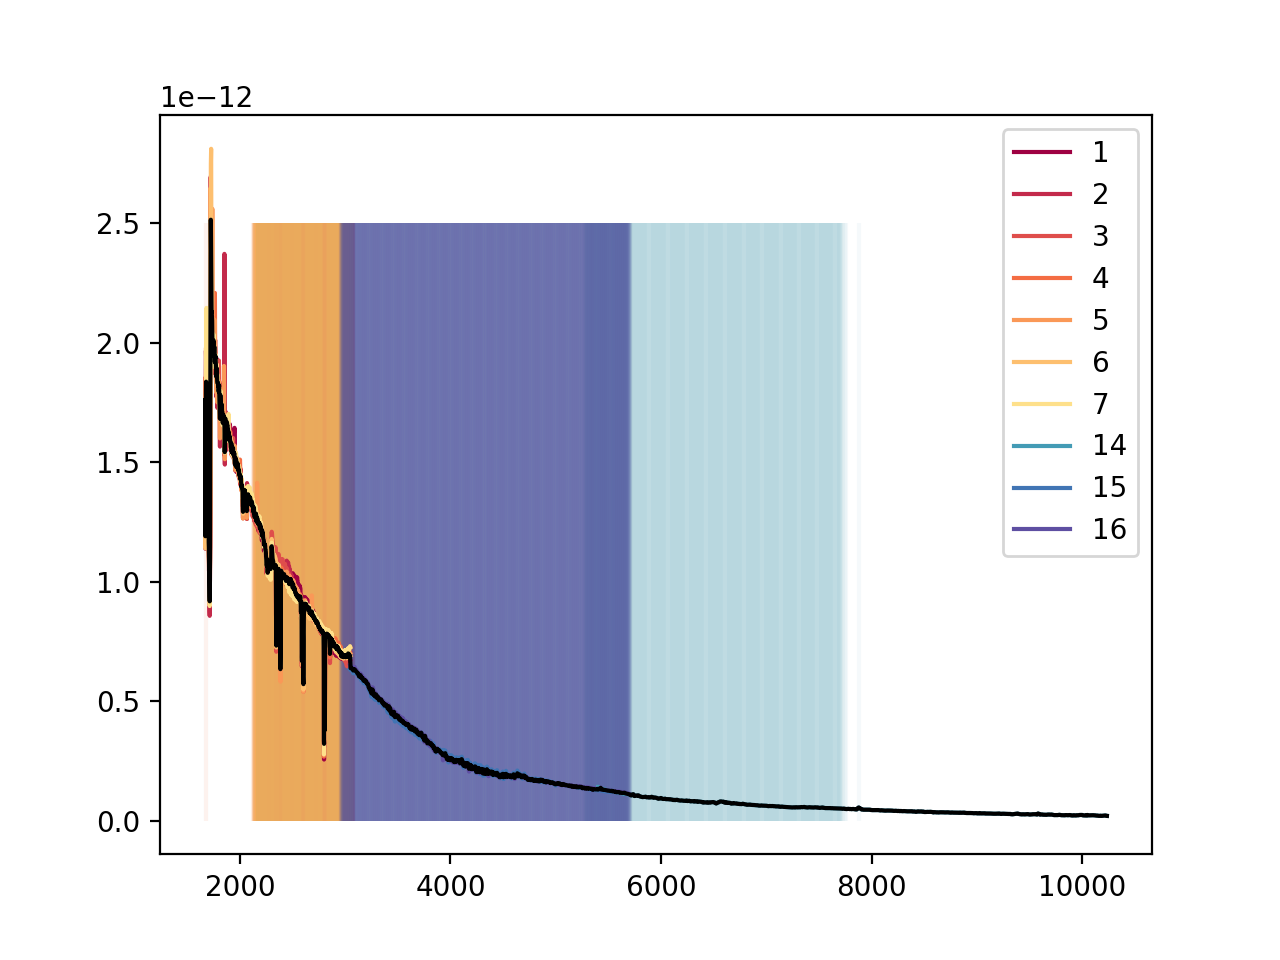

In [84]:
f, ax = plt.subplots()
ax.plot(spec1_v3.spectral_axis, spec1_v3.flux, label='1', color=colors[0])
ax.plot(spec2_v3.spectral_axis, spec2_v3.flux, label='2', color=colors[1])
ax.plot(spec3_v3.spectral_axis, spec3_v3.flux, label='3', color=colors[2])
ax.plot(spec4_v3.spectral_axis, spec4_v3.flux, label='4', color=colors[3])
ax.plot(spec5_v3.spectral_axis, spec5_v3.flux, label='5', color=colors[4])
ax.plot(spec6_v3.spectral_axis, spec6_v3.flux, label='6', color=colors[5])
ax.plot(spec7_v3.spectral_axis, spec7_v3.flux, label='7', color=colors[6])
ax.plot(spec14_v3.spectral_axis, spec14_v3.flux*1.15, label='14', color=colors[13])
ax.plot(spec15_v3.spectral_axis, spec15_v3.flux, label='15', color=colors[14])
ax.plot(spec16_v3.spectral_axis, spec16_v3.flux, label='16', color=colors[15])
ax.plot(combined_spectrum_v3.spectral_axis, combined_spectrum_v3.flux, color='k')
plt.legend()

for indx, (ifile, color) in enumerate(zip(flist_v3[:6]+flist_v3[13:], list(colors[:6])+list(colors[13:]))):
    if indx>=9:
        continue
    plot_saturated(ifile, ax, ymax=2.5E-12, color=color)

# Visit 4

In [88]:
flist_v4 = glob.glob('../data/spectra/HST/oezt04*x1d.fits')
flist_v4.sort()
flist_v4[-3] = flist_v4[-3].replace('x1d', 'dsx1')
flist_v4[-4] = flist_v4[-4].replace('x1d', 'dsx1')

In [89]:
# There are slit losses from the object saturating the acqusition images. 
# Exposure 12 has the highest flux and seems to match the optical spectra as well
spec3_v4 = prepare_spectrum_v2(flist_v4[2], new_spectral_axis)

In [90]:
spec1_v4 =  prepare_spectrum_v2(flist_v4[0], new_spectral_axis, scale_spectrum=spec3_v4)
spec2_v4 =  prepare_spectrum_v2(flist_v4[1], new_spectral_axis, scale_spectrum=spec3_v4)
#spec3_v4 =  prepare_spectrum_v2(flist_v4[2], new_spectral_axis)
spec4_v4 =  prepare_spectrum_v2(flist_v4[3], new_spectral_axis, scale_spectrum=spec3_v4)
spec5_v4 =  prepare_spectrum_v2(flist_v4[4], new_spectral_axis, scale_spectrum=spec3_v4)
spec6_v4 =  prepare_spectrum_v2(flist_v4[5], new_spectral_axis, scale_spectrum=spec3_v4)
spec7_v4 =  prepare_spectrum_v2(flist_v4[6], new_spectral_axis, scale_spectrum=spec3_v4)
spec8_v4 =  prepare_spectrum_v2(flist_v4[7], new_spectral_axis, scale_spectrum=spec3_v4)
spec9_v4 =  prepare_spectrum_v2(flist_v4[8], new_spectral_axis, scale_spectrum=spec3_v4)
spec10_v4 = prepare_spectrum_v2(flist_v4[9], new_spectral_axis)
spec11_v4 = prepare_spectrum_v2(flist_v4[10], new_spectral_axis)
spec12_v4 = prepare_spectrum_v2(flist_v4[11], new_spectral_axis)
spec13_v4 = prepare_spectrum_v2(flist_v4[12], new_spectral_axis)

/var/folders/6l/54htg8p52b762n_6mhsb13v80000gn/T/ipykernel_32082/3763175262.py:17: RuntimeWarning: invalid value encountered in divide
  ratio = median_smooth(new_spec, width=5).flux.value/median_smooth(scale_spectrum, width=5).flux.value


In [91]:
combined_flux_v4 = np.nanmedian(np.vstack([ spec1_v4.flux.value, spec2_v4.flux.value,
                                            spec3_v4.flux.value, spec4_v4.flux.value, spec5_v4.flux.value,  
                                            spec6_v4.flux.value, spec7_v4.flux.value, 
                                            spec8_v4.flux.value, 
                                            spec9_v4.flux.value,
                                            spec10_v4.flux.value*1.15,
                                            spec11_v4.flux.value*1.15,
                                            spec12_v4.flux.value,
                                            spec13_v4.flux.value]), 
                                axis=0)*u.erg/u.cm**2/u.s/u.angstrom
combined_spectrum_v4 = Spectrum1D(spectral_axis=new_spectral_axis, flux=combined_flux_v4)

<IPython.core.display.Javascript object>


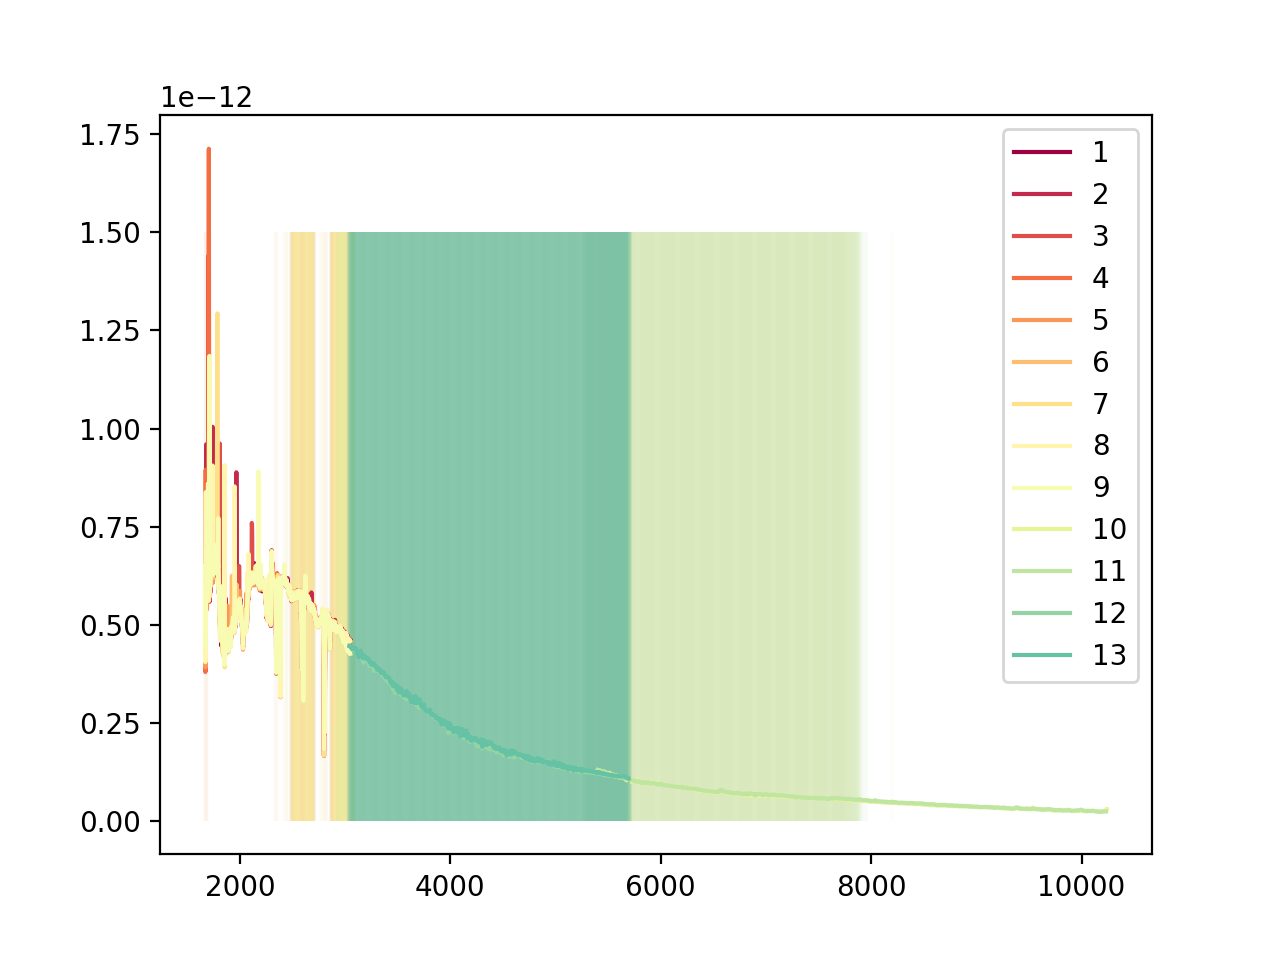

In [92]:
f, ax = plt.subplots()
ax.plot(spec1_v4.spectral_axis, spec1_v4.flux, label='1', color=colors[0])
ax.plot(spec2_v4.spectral_axis, spec2_v4.flux, label='2', color=colors[1])
ax.plot(spec3_v4.spectral_axis, spec3_v4.flux, label='3', color=colors[2])
ax.plot(spec4_v4.spectral_axis, spec4_v4.flux, label='4', color=colors[3])
ax.plot(spec5_v4.spectral_axis, spec5_v4.flux, label='5', color=colors[4])
ax.plot(spec6_v4.spectral_axis, spec6_v4.flux, label='6', color=colors[5])
ax.plot(spec7_v4.spectral_axis, spec7_v4.flux, label='7', color=colors[6])
ax.plot(spec8_v4.spectral_axis, spec8_v4.flux, label='8', color=colors[7])
ax.plot(spec9_v4.spectral_axis, spec9_v4.flux, label='9', color=colors[8])
ax.plot(spec10_v4.spectral_axis, spec10_v4.flux*1.15, label='10', color=colors[9])
ax.plot(spec11_v4.spectral_axis, spec11_v4.flux*1.15, label='11', color=colors[10])
ax.plot(spec12_v4.spectral_axis, spec12_v4.flux, label='12', color=colors[11])
ax.plot(spec13_v4.spectral_axis, spec13_v4.flux, label='13', color=colors[12])
#ax.plot(combined_spectrum_v4.spectral_axis, combined_spectrum_v4.flux, color='k')
plt.legend()

for ifile, color in zip(flist_v4[:13], colors):
    plot_saturated(ifile, ax, ymax=1.5E-12, color=color)


# Visit 5

In [93]:
flist_v5 = glob.glob('../data/spectra/HST/oezt05*x1d.fits')
flist_v5.sort()
flist_v5[-3] = flist_v5[-3].replace('x1d', 'dsx1')
flist_v5[-4] = flist_v5[-4].replace('x1d', 'dsx1')

In [94]:
# There are slit losses from the object saturating the acqusition images. 
# Exposure 12 has the highest flux and seems to match the optical spectra as well
spec3_v5 = prepare_spectrum_v2(flist_v5[2], new_spectral_axis)

In [95]:
spec1_v5 =  prepare_spectrum_v2(flist_v5[0], new_spectral_axis)
spec2_v5 =  prepare_spectrum_v2(flist_v5[1], new_spectral_axis)
spec3_v5 =  prepare_spectrum_v2(flist_v5[2], new_spectral_axis)
spec4_v5 =  prepare_spectrum_v2(flist_v5[3], new_spectral_axis)
spec5_v5 =  prepare_spectrum_v2(flist_v5[4], new_spectral_axis)
spec6_v5 =  prepare_spectrum_v2(flist_v5[5], new_spectral_axis)
spec7_v5 =  prepare_spectrum_v2(flist_v5[6], new_spectral_axis)
spec8_v5 =  prepare_spectrum_v2(flist_v5[7], new_spectral_axis)
spec9_v5 =  prepare_spectrum_v2(flist_v5[8], new_spectral_axis)
spec10_v5 = prepare_spectrum_v2(flist_v5[9], new_spectral_axis)

In [96]:
combined_flux_v5 = np.nanmedian(np.vstack([ spec1_v5.flux.value, spec2_v5.flux.value,
                                            spec3_v5.flux.value, spec4_v5.flux.value, spec5_v5.flux.value,  
                                            spec6_v5.flux.value, 
                                            spec7_v5.flux.value*1.05, 
                                            spec8_v5.flux.value*1.05, 
                                            spec9_v5.flux.value,
                                            spec10_v5.flux.value]), 
                                axis=0)*u.erg/u.cm**2/u.s/u.angstrom
combined_spectrum_v5 = Spectrum1D(spectral_axis=new_spectral_axis, flux=combined_flux_v5)

<IPython.core.display.Javascript object>


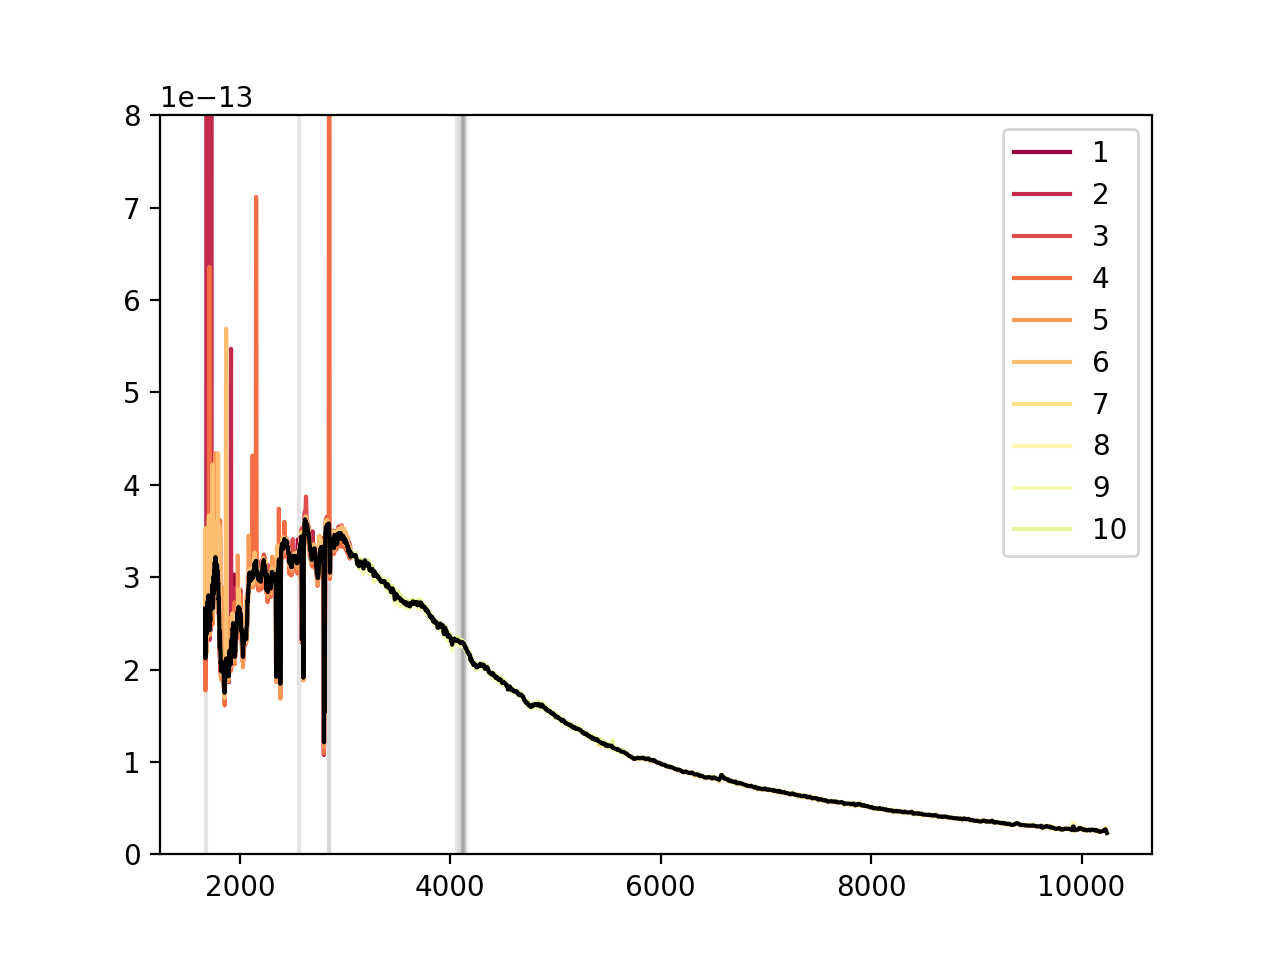

In [97]:
f, ax = plt.subplots()
ax.plot(spec1_v5.spectral_axis, spec1_v5.flux, label='1', color=colors[0])
ax.plot(spec2_v5.spectral_axis, spec2_v5.flux, label='2', color=colors[1])
ax.plot(spec3_v5.spectral_axis, spec3_v5.flux, label='3', color=colors[2])
ax.plot(spec4_v5.spectral_axis, spec4_v5.flux, label='4', color=colors[3])
ax.plot(spec5_v5.spectral_axis, spec5_v5.flux, label='5', color=colors[4])
ax.plot(spec6_v5.spectral_axis, spec6_v5.flux, label='6', color=colors[5])
ax.plot(spec7_v5.spectral_axis, spec7_v5.flux*1.05, label='7', color=colors[6])
ax.plot(spec8_v5.spectral_axis, spec8_v5.flux*1.05, label='8', color=colors[7])
ax.plot(spec9_v5.spectral_axis, spec9_v5.flux, label='9', color=colors[8])
ax.plot(spec10_v5.spectral_axis, spec10_v5.flux, label='10', color=colors[9])
ax.plot(combined_spectrum_v5.spectral_axis, combined_spectrum_v5.flux, color='k')
plt.legend()
plt.ylim(0, 8E-13)

for ifile in flist_v5:
    plot_saturated(ifile, ax, ymax=3E-12)

In [99]:
for ifile in flist_v5:
    print(fits.getval(ifile, 'OPT_ELEM', 0))

G230LB
G230LB
G230LB
G230LB
G230LB
G230LB
G750L
G750L
G430L
G430L


# My visit 1

In [100]:
def prepare_spectrum_DD(filename,  new_spectral_axis, scale_spectrum=None):
    opt_elem = fits.getval(filename, 'OPT_ELEM', 0)
    tbdata = fits.getdata(filename, 1)
    good_indx = ((tbdata['DQ']&16!=16) & (tbdata['DQ']&512!=512))
    spec = specutils.hst_stis.Spectrum1D(spectral_axis=tbdata['WAVELENGTH'][good_indx]*u.angstrom, flux=tbdata['FLUX'][good_indx]*u.erg/u.cm**2/u.s/u.angstrom)
    if opt_elem == 'G750L':
        spec = resampler(spec, u.angstrom*np.arange(spec.spectral_axis.value.max(), 5400, -np.diff(spec.spectral_axis.value)[0])[::-1])

    if opt_elem == 'G430L':
        spec = resampler(spec, u.angstrom*np.arange(spec.spectral_axis.value.max(), 3040, -np.diff(spec.spectral_axis.value)[0])[::-1])

    if opt_elem == 'G230LB':
        spec = resampler(spec, u.angstrom*np.arange(spec.spectral_axis.value.min(), 3050, np.diff(spec.spectral_axis.value)[0]))
    
    new_spec = resampler(spec, new_spectral_axis)
    if scale_spectrum:
        ratio = median_smooth(new_spec, width=5).flux.value/median_smooth(scale_spectrum, width=5).flux.value
        nan_indx = np.isnan(ratio)
        fit_params = np.polyfit(new_spectral_axis.value[~nan_indx][400:800],ratio[~nan_indx][400:800] , 1)
        scale = np.polyval(fit_params, new_spectral_axis.value)
        new_spec = new_spec/scale
    return new_spec

In [101]:
flist_v6 = glob.glob('../data/spectra/HST/of43010*sx1.fits')
flist_v6.sort()
flist_v6 = flist_v6[:-1]

In [102]:
spec1_v6 =  prepare_spectrum_DD(flist_v6[0], new_spectral_axis)
spec2_v6 =  prepare_spectrum_DD(flist_v6[1], new_spectral_axis)
spec3_v6 =  prepare_spectrum_DD(flist_v6[2], new_spectral_axis)


In [103]:
combined_flux_v6 = np.nanmedian(np.vstack([ spec1_v6.flux.value, spec2_v6.flux.value,
                                            spec3_v6.flux.value]), 
                                axis=0)*u.erg/u.cm**2/u.s/u.angstrom
combined_spectrum_v6 = Spectrum1D(spectral_axis=new_spectral_axis, flux=combined_flux_v6)

<IPython.core.display.Javascript object>


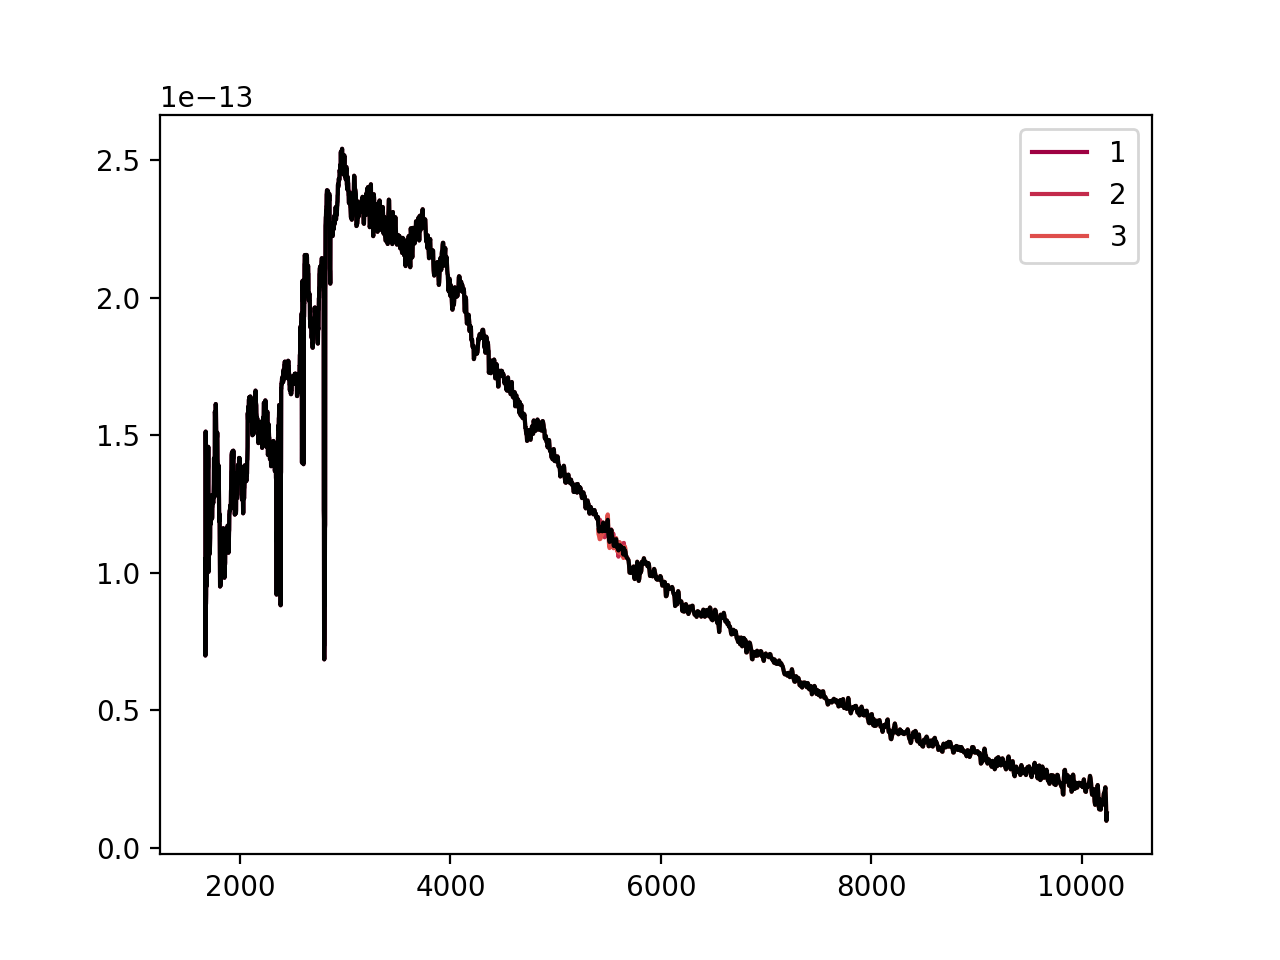

In [104]:
f, ax = plt.subplots()
ax.plot(spec1_v6.spectral_axis, spec1_v6.flux, label='1', color=colors[0])
ax.plot(spec2_v6.spectral_axis, spec2_v6.flux, label='2', color=colors[1])
ax.plot(spec3_v6.spectral_axis, spec3_v6.flux, label='3', color=colors[2])
ax.plot(combined_spectrum_v6.spectral_axis, combined_spectrum_v6.flux, color='k')
plt.legend()

# My visit 2

In [105]:
flist_v7 = glob.glob('../data/spectra/HST/of43020*sx1.fits')
flist_v7.sort()
flist_v7 = flist_v7[:-1]
flist_v7

['../data/spectra/HST/of4302010_sx1.fits',
 '../data/spectra/HST/of4302020_sx1.fits',
 '../data/spectra/HST/of4302030_dsx1.fits']

In [106]:
spec1_v7 =  prepare_spectrum_DD(flist_v7[0], new_spectral_axis)
spec2_v7 =  prepare_spectrum_DD(flist_v7[1], new_spectral_axis)
spec3_v7 =  prepare_spectrum_DD(flist_v7[2], new_spectral_axis)

combined_flux_v7 = np.nanmedian(np.vstack([ spec1_v7.flux.value, spec2_v7.flux.value,
                                            spec3_v7.flux.value]), 
                                axis=0)*u.erg/u.cm**2/u.s/u.angstrom
combined_spectrum_v7 = Spectrum1D(spectral_axis=new_spectral_axis, flux=combined_flux_v7)

<IPython.core.display.Javascript object>


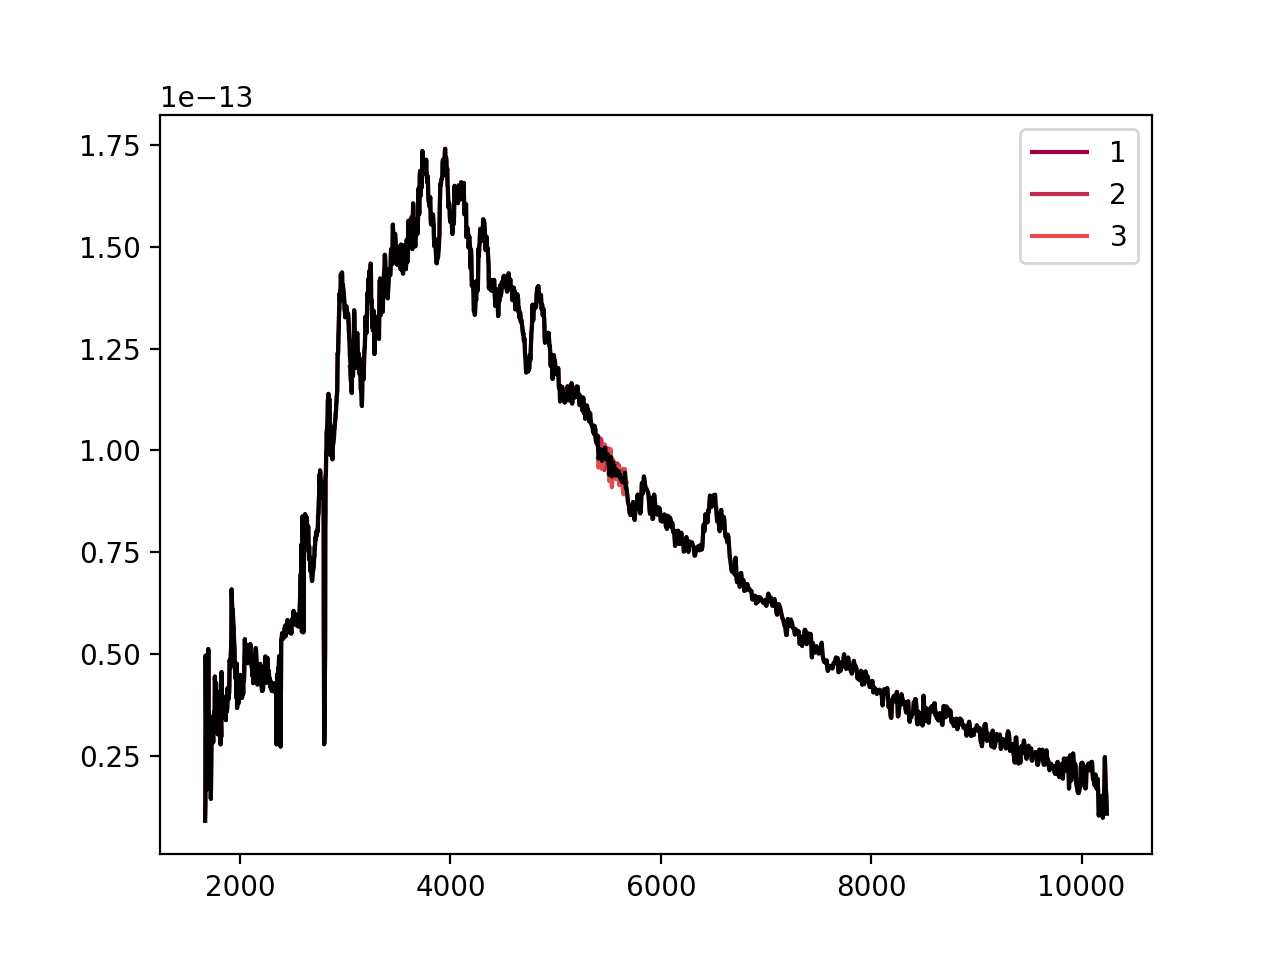

In [107]:
f, ax = plt.subplots()
ax.plot(spec1_v7.spectral_axis, spec1_v7.flux, label='1', color=colors[0])
ax.plot(spec2_v7.spectral_axis, spec2_v7.flux, label='2', color=colors[1])
ax.plot(spec3_v7.spectral_axis, spec3_v7.flux, label='3', color=colors[2])
ax.plot(combined_spectrum_v7.spectral_axis, combined_spectrum_v7.flux, color='k')
plt.legend()

# My Visit 3

In [108]:
flist_v8 = glob.glob('../data/spectra/HST/of43030*sx1.fits')
flist_v8.sort()
flist_v8 = flist_v8[:-1]
flist_v8

['../data/spectra/HST/of4303010_sx1.fits',
 '../data/spectra/HST/of4303020_sx1.fits',
 '../data/spectra/HST/of4303030_dsx1.fits']

In [109]:
spec1_v8 =  prepare_spectrum_DD(flist_v8[0], new_spectral_axis)
spec2_v8 =  prepare_spectrum_DD(flist_v8[1], new_spectral_axis)
spec3_v8 =  prepare_spectrum_DD(flist_v8[2], new_spectral_axis)

combined_flux_v8 = np.nanmedian(np.vstack([ spec1_v8.flux.value, spec2_v8.flux.value,
                                            spec3_v8.flux.value]), 
                                axis=0)*u.erg/u.cm**2/u.s/u.angstrom
combined_spectrum_v8 = Spectrum1D(spectral_axis=new_spectral_axis, flux=combined_flux_v8)

<IPython.core.display.Javascript object>


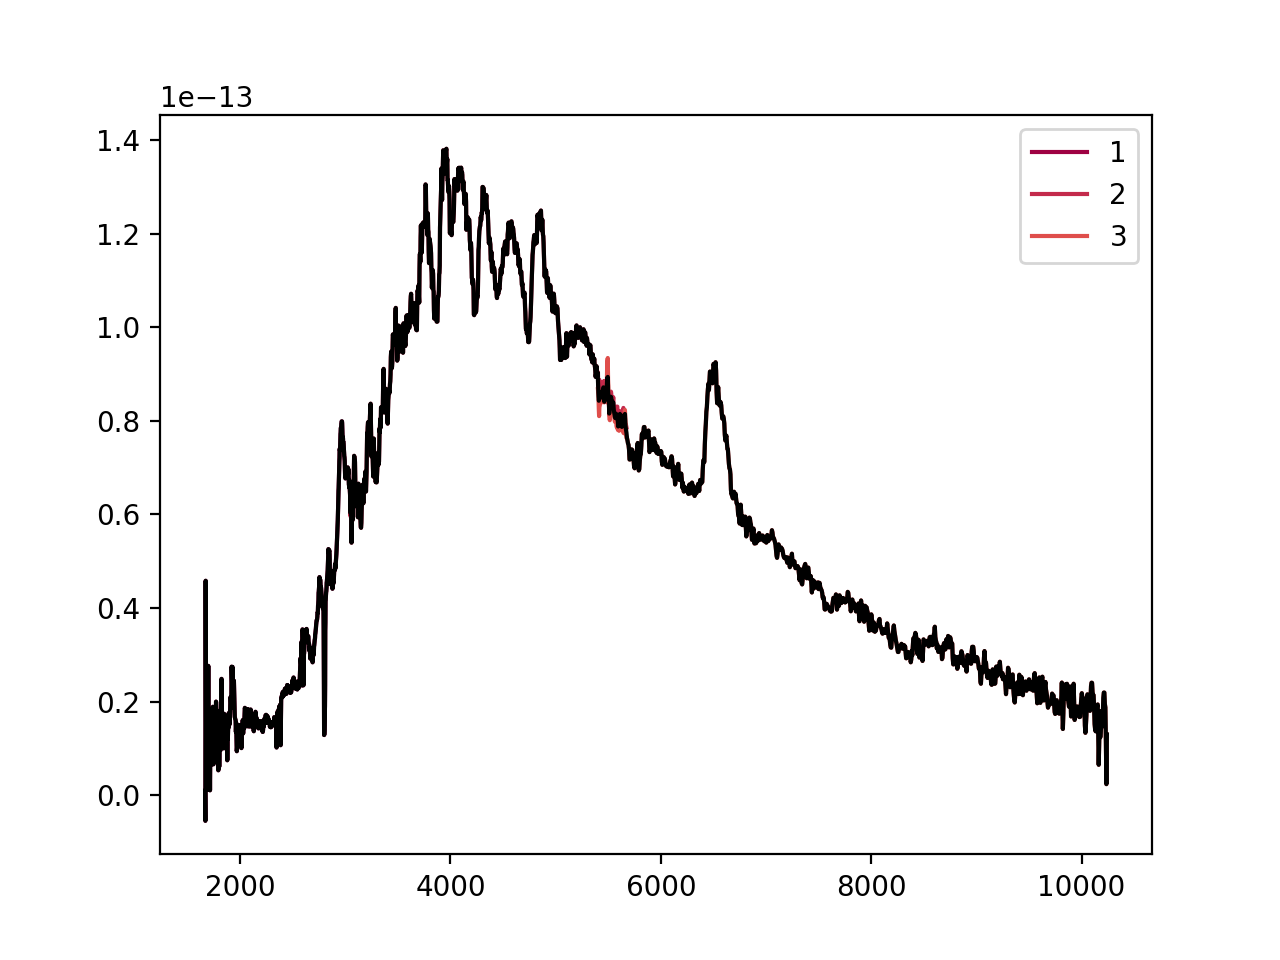

In [110]:
f, ax = plt.subplots()
ax.plot(spec1_v8.spectral_axis, spec1_v8.flux, label='1', color=colors[0])
ax.plot(spec2_v8.spectral_axis, spec2_v8.flux, label='2', color=colors[1])
ax.plot(spec3_v8.spectral_axis, spec3_v8.flux, label='3', color=colors[2])
ax.plot(combined_spectrum_v8.spectral_axis, combined_spectrum_v8.flux, color='k')
plt.legend()

# My Visit 5

In [111]:
flist_v9 = glob.glob('../data/spectra/HST/of43050*sx1.fits')
flist_v9.sort()
flist_v9 = flist_v9[:-1]
flist_v9

['../data/spectra/HST/of4305010_sx1.fits',
 '../data/spectra/HST/of4305020_sx1.fits',
 '../data/spectra/HST/of4305030_dsx1.fits']

In [112]:
spec1_v9 =  prepare_spectrum_DD(flist_v9[0], new_spectral_axis)
spec2_v9 =  prepare_spectrum_DD(flist_v9[1], new_spectral_axis)
spec3_v9 =  prepare_spectrum_DD(flist_v9[2], new_spectral_axis)

combined_flux_v9 = np.nanmedian(np.vstack([ spec1_v9.flux.value, spec2_v9.flux.value,
                                            spec3_v9.flux.value]), 
                                axis=0)*u.erg/u.cm**2/u.s/u.angstrom
combined_spectrum_v9 = Spectrum1D(spectral_axis=new_spectral_axis, flux=combined_flux_v9)

<IPython.core.display.Javascript object>


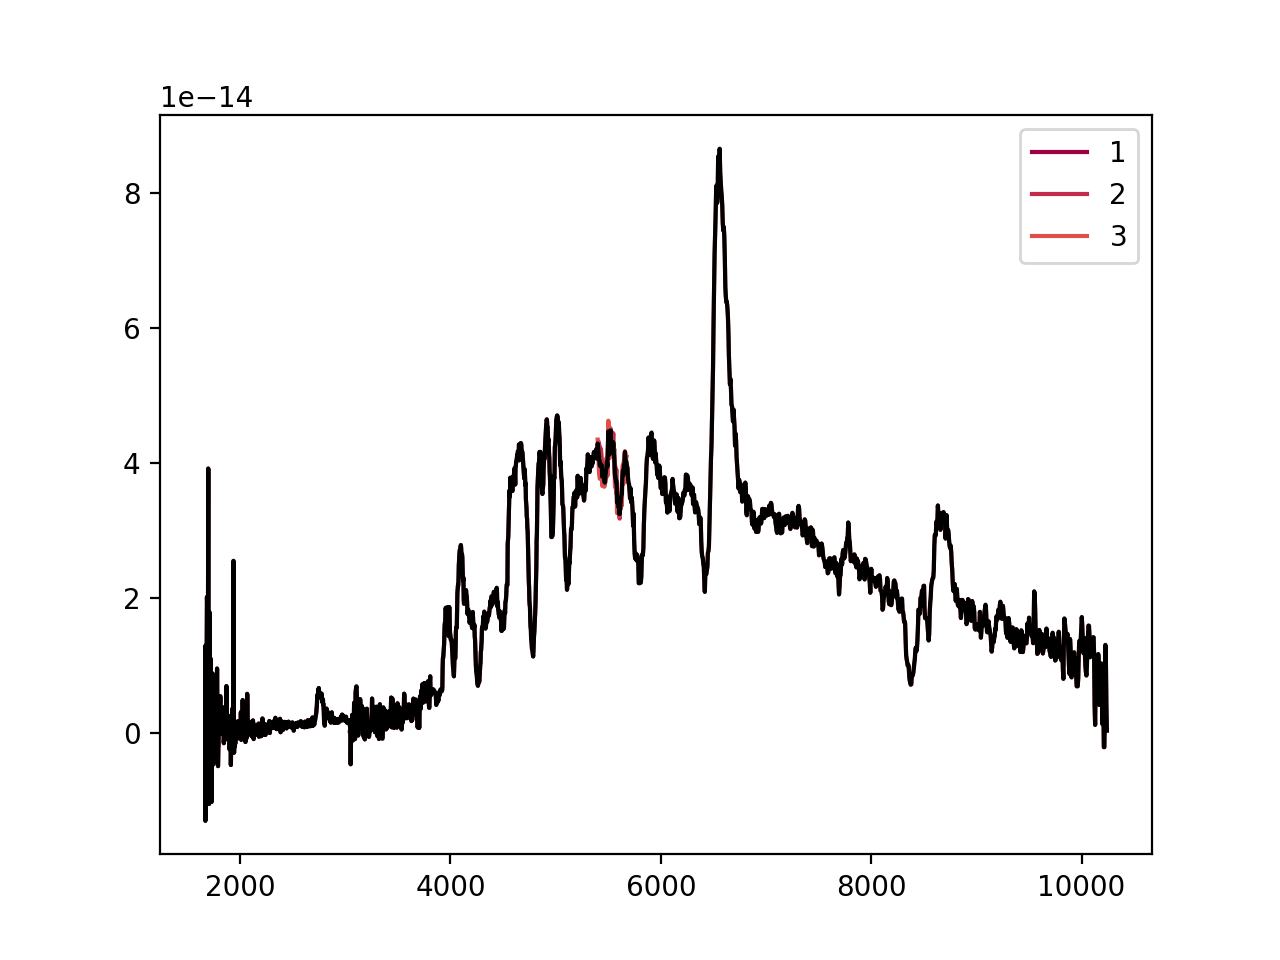

In [113]:
f, ax = plt.subplots()
ax.plot(spec1_v9.spectral_axis, spec1_v9.flux, label='1', color=colors[0])
ax.plot(spec2_v9.spectral_axis, spec2_v9.flux, label='2', color=colors[1])
ax.plot(spec3_v9.spectral_axis, spec3_v9.flux, label='3', color=colors[2])
ax.plot(combined_spectrum_v9.spectral_axis, combined_spectrum_v9.flux, color='k')
plt.legend()

# All visits

In [114]:
params = json.load(open('../../sn2023ixf/data/sn23ixf_params.js', 'r'))
phase_list = []
for ilist in [flist_v1, flist_v2, flist_v3, flist_v4, flist_v5, flist_v6, flist_v7, flist_v8, flist_v9]:
    phase = Time(fits.getval(ilist[0], 'TDATEOBS', 0))
    phase_list.append((phase-Time(params['reftime'])).value)

In [115]:
phase_list

[3.25, 4.25, 5.25, 8.25, 11.25, 14.25, 19.25, 24.25, 66.25]

In [116]:
all_colors = viz.make_color_wheel(11, cmap='ocean')

<IPython.core.display.Javascript object>


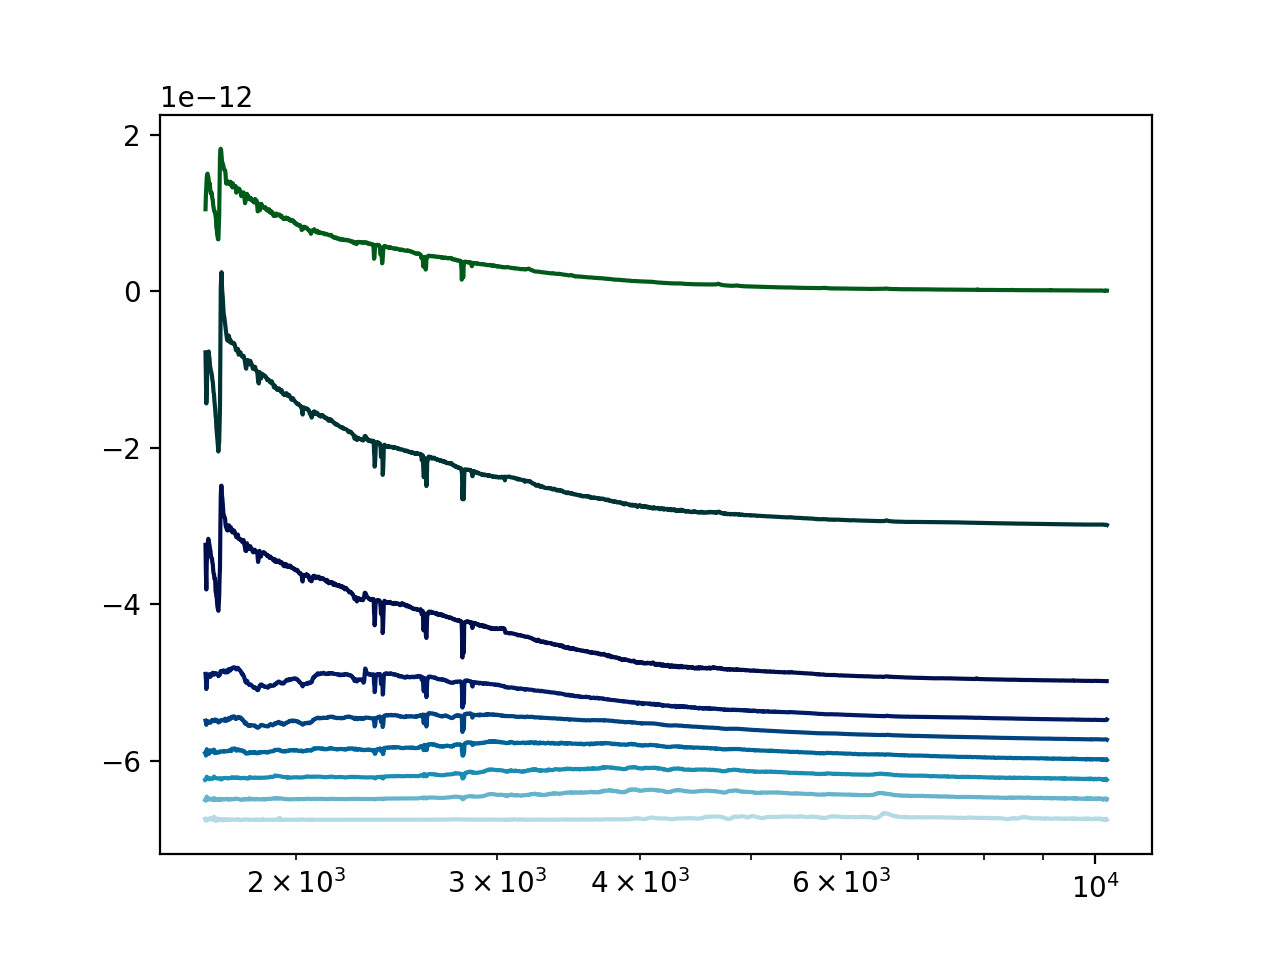

In [117]:
f, ax = plt.subplots()
ax.semilogx(combined_spectrum_v1.spectral_axis, combined_spectrum_v1.flux, color=all_colors[1])
ax.semilogx(combined_spectrum_v2.spectral_axis, combined_spectrum_v2.flux.value-3E-12, color=all_colors[2])
ax.semilogx(combined_spectrum_v3.spectral_axis, combined_spectrum_v3.flux.value-5E-12, color=all_colors[3])
ax.semilogx(combined_spectrum_v4.spectral_axis, combined_spectrum_v4.flux.value-5.5E-12, color=all_colors[4])
ax.semilogx(combined_spectrum_v5.spectral_axis, combined_spectrum_v5.flux.value-5.75E-12, color=all_colors[5])
ax.semilogx(combined_spectrum_v6.spectral_axis, combined_spectrum_v6.flux.value-6E-12, color=all_colors[6])
ax.semilogx(combined_spectrum_v7.spectral_axis, combined_spectrum_v7.flux.value-6.25E-12, color=all_colors[7])
ax.semilogx(combined_spectrum_v8.spectral_axis, combined_spectrum_v8.flux.value-6.5E-12, color=all_colors[8])
ax.semilogx(combined_spectrum_v9.spectral_axis, combined_spectrum_v9.flux.value-6.75E-12, color=all_colors[9])


<IPython.core.display.Javascript object>


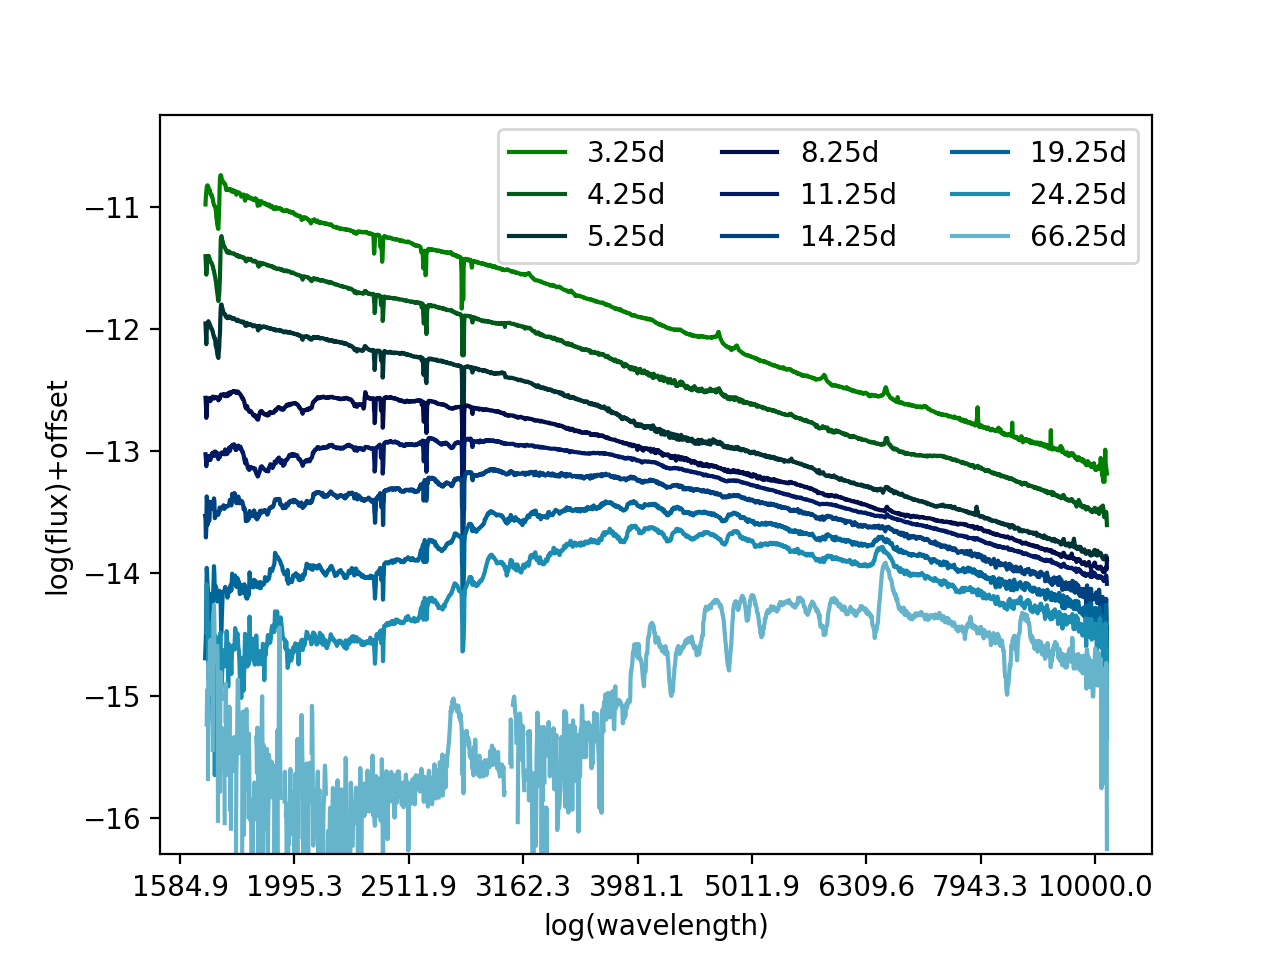

/var/folders/6l/54htg8p52b762n_6mhsb13v80000gn/T/ipykernel_32082/412909784.py:9: RuntimeWarning: invalid value encountered in log10
  ax.plot(np.log10(combined_spectrum_v8.spectral_axis.value), np.log10(combined_spectrum_v8.flux.value)-0.75, color=all_colors[7], label=f'{phase_list[7]}d')
/var/folders/6l/54htg8p52b762n_6mhsb13v80000gn/T/ipykernel_32082/412909784.py:10: RuntimeWarning: invalid value encountered in log10
  ax.plot(np.log10(combined_spectrum_v9.spectral_axis.value), np.log10(combined_spectrum_v9.flux.value)-0.85, color=all_colors[8], label=f'{phase_list[8]}d')
/var/folders/6l/54htg8p52b762n_6mhsb13v80000gn/T/ipykernel_32082/412909784.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{itick:2.1f}' for itick in 10**(ax.get_xticks())])


In [123]:
f, ax = plt.subplots()
ax.plot(np.log10(combined_spectrum_v1.spectral_axis.value), np.log10(combined_spectrum_v1.flux.value)+1, color=all_colors[0], label=f'{phase_list[0]}d')
ax.plot(np.log10(combined_spectrum_v2.spectral_axis.value), np.log10(combined_spectrum_v2.flux.value)+0.25, color=all_colors[1], label=f'{phase_list[1]}d')
ax.plot(np.log10(combined_spectrum_v3.spectral_axis.value), np.log10(combined_spectrum_v3.flux.value)-0.2, color=all_colors[2], label=f'{phase_list[2]}d')
ax.plot(np.log10(combined_spectrum_v4.spectral_axis.value), np.log10(combined_spectrum_v4.flux.value)-0.35, color=all_colors[3], label=f'{phase_list[3]}d')
ax.plot(np.log10(combined_spectrum_v5.spectral_axis.value), np.log10(combined_spectrum_v5.flux.value)-0.45, color=all_colors[4], label=f'{phase_list[4]}d')
ax.plot(np.log10(combined_spectrum_v6.spectral_axis.value), np.log10(combined_spectrum_v6.flux.value)-0.55, color=all_colors[5], label=f'{phase_list[5]}d')
ax.plot(np.log10(combined_spectrum_v7.spectral_axis.value), np.log10(combined_spectrum_v7.flux.value)-0.65, color=all_colors[6], label=f'{phase_list[6]}d')
ax.plot(np.log10(combined_spectrum_v8.spectral_axis.value), np.log10(combined_spectrum_v8.flux.value)-0.75, color=all_colors[7], label=f'{phase_list[7]}d')
ax.plot(np.log10(combined_spectrum_v9.spectral_axis.value), np.log10(combined_spectrum_v9.flux.value)-0.85, color=all_colors[8], label=f'{phase_list[8]}d')
ax.set_xlabel('log(wavelength)')
ax.set_ylabel('log(flux)+offset')
ax.set_xticklabels([f'{itick:2.1f}' for itick in 10**(ax.get_xticks())])
#ax.set_yticks([])
ax.set_ylim(-16.3, -10.25)
plt.legend(ncol=3)

In [122]:
combined_spectrum_v1.write('../data/spectra/HST/combined_v1_GO.fits', overwrite=True)
combined_spectrum_v2.write('../data/spectra/HST/combined_v2_GO.fits', overwrite=True)
combined_spectrum_v3.write('../data/spectra/HST/combined_v3_GO.fits', overwrite=True)
combined_spectrum_v4.write('../data/spectra/HST/combined_v4_GO.fits', overwrite=True)
combined_spectrum_v5.write('../data/spectra/HST/combined_v5_GO.fits', overwrite=True)

combined_spectrum_v6.write('../data/spectra/HST/combined_v1_DD.fits', overwrite=True)
combined_spectrum_v7.write('../data/spectra/HST/combined_v2_DD.fits', overwrite=True)
combined_spectrum_v8.write('../data/spectra/HST/combined_v3_DD.fits', overwrite=True)
combined_spectrum_v9.write('../data/spectra/HST/combined_v5_DD.fits', overwrite=True)

# Check extraction

<IPython.core.display.Javascript object>


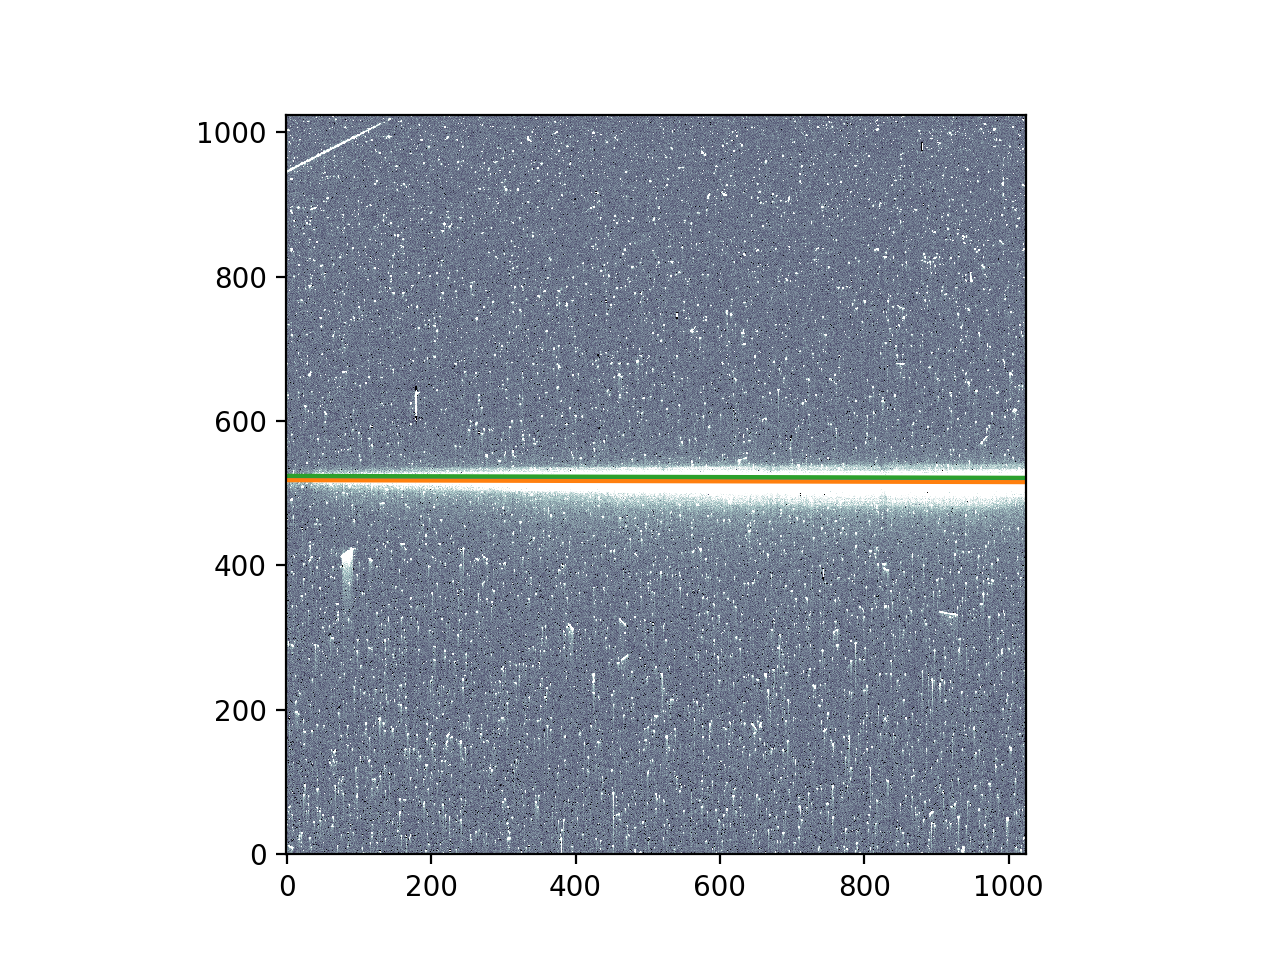

In [212]:
f, ax = plt.subplots()
img = fits.getdata(flist_v3[4].replace('x1d', 'flt'), 1)
vmin, vmax = viz.zscale(img)
ax.imshow(img, interpolation='nearest', vmin=vmin, vmax=vmax, cmap='bone')
spec = fits.getdata(flist_v3[4], 1)
pix = np.arange(0, 1024)
ax.plot(pix, spec['extrlocy'][0])
ax.plot(pix, spec['extrlocy'][0]-spec['EXTRSIZE'][0]//2)
ax.plot(pix,spec['extrlocy'][0]+spec['EXTRSIZE'][0]//2)

<IPython.core.display.Javascript object>


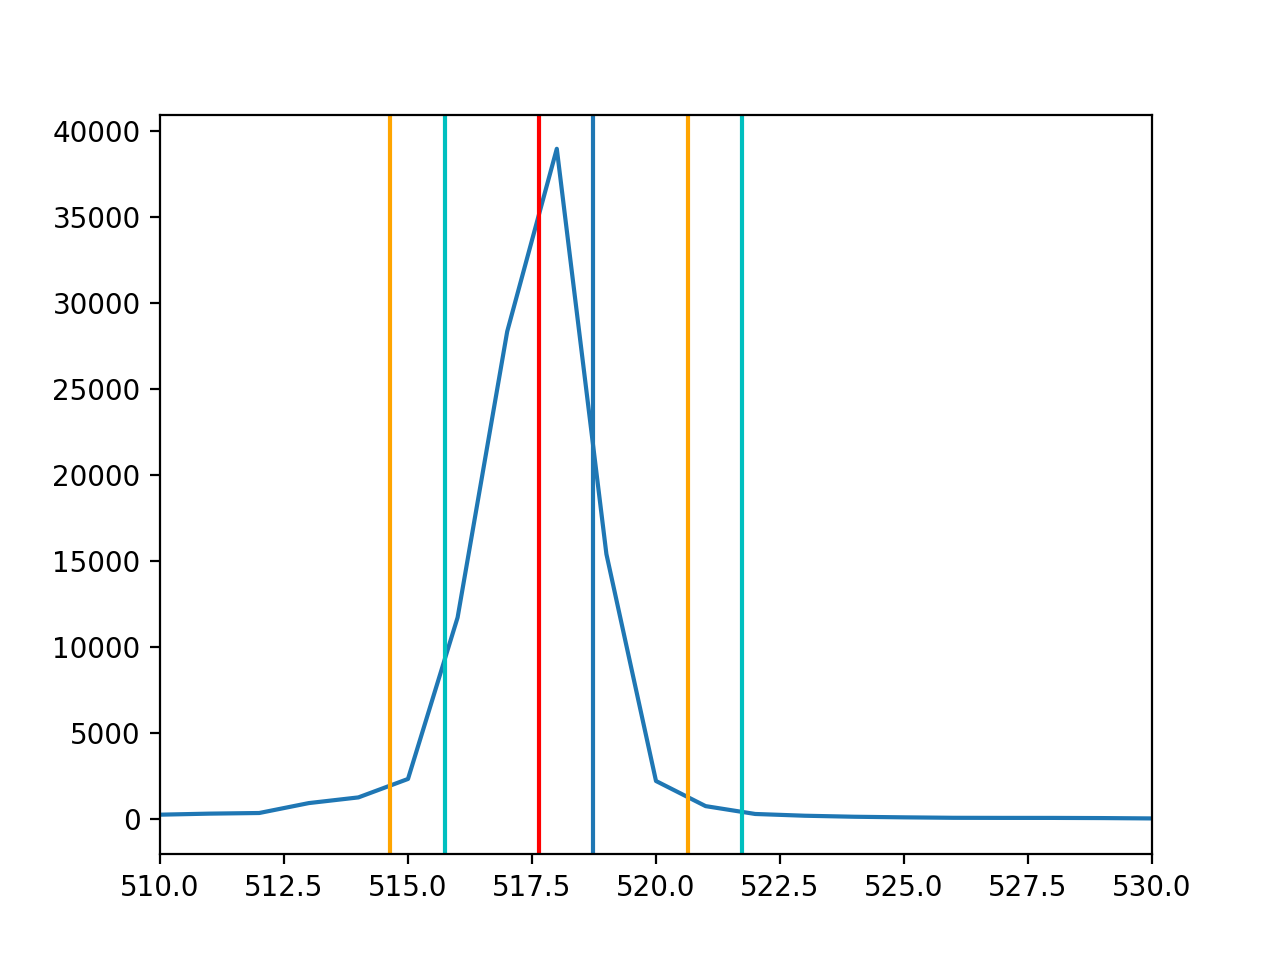

(510.0, 530.0)

In [216]:
f, ax = plt.subplots()
img = fits.getdata(flist_v3[4].replace('x1d', 'flt'), 1)
pix = np.arange(0, 1024)
ax.plot(pix, img[:, 800])
spec = fits.getdata(flist_v3[4], 1)

ax.axvline( (spec['extrlocy'][0][800]))
ax.axvline( (spec['extrlocy'][0][800]-spec['EXTRSIZE'][0]//2), color='c')
ax.axvline((spec['extrlocy'][0][800]+spec['EXTRSIZE'][0]//2), color='c')

ax.axvline( spec['extrlocy'][0][800]-1.1, color='r')
ax.axvline( (spec['extrlocy'][0][800]-1.1-spec['EXTRSIZE'][0]//2), color='orange')
ax.axvline((spec['extrlocy'][0][800]-1.1+spec['EXTRSIZE'][0]//2), color='orange')
ax.set_xlim(510, 530)

<IPython.core.display.Javascript object>


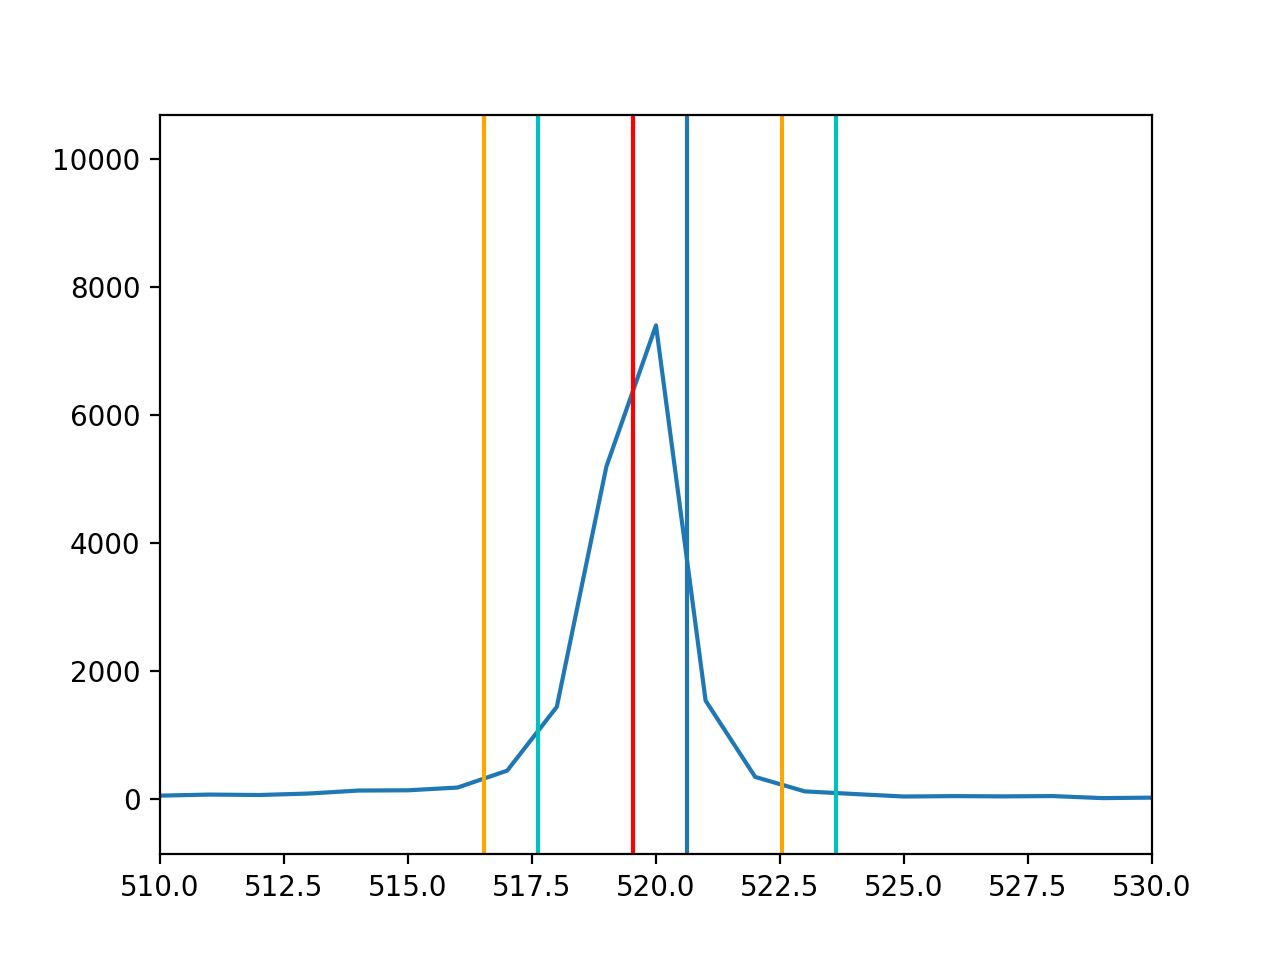

(510.0, 530.0)

In [215]:
f, ax = plt.subplots()
img = fits.getdata(flist_v3[4].replace('x1d', 'flt'), 1)
pix = np.arange(0, 1024)
ax.plot(pix, img[:, 100])
spec = fits.getdata(flist_v3[4], 1)

ax.axvline( (spec['extrlocy'][0][100]))
ax.axvline( (spec['extrlocy'][0][100]-spec['EXTRSIZE'][0]//2), color='c')
ax.axvline((spec['extrlocy'][0][100]+spec['EXTRSIZE'][0]//2), color='c')

ax.axvline( spec['extrlocy'][0][100]-1.1, color='r')
ax.axvline( (spec['extrlocy'][0][100]-1.1-spec['EXTRSIZE'][0]//2), color='orange')
ax.axvline((spec['extrlocy'][0][100]-1.1+spec['EXTRSIZE'][0]//2), color='orange')
ax.set_xlim(510, 530)

In [208]:
spec['A2CENTER'][0], spec['EXTRLOCY'][0]

(509.93915,
 array([511.2764 , 511.27347, 511.2705 , ..., 508.55844, 508.55557,
        508.55276], dtype=float32))

In [544]:
fits.getval(flist_v1[0], 'PROPOSID', 0)

17205

In [120]:
for ilist in [flist_v1, flist_v2, flist_v3, flist_v4, flist_v5, flist_v6, flist_v7, flist_v8, flist_v9]:
    print(ilist[0])

../data/spectra/HST/oezt01010_x1d.fits
../data/spectra/HST/oezt02010_x1d.fits
../data/spectra/HST/oezt03010_x1d.fits
../data/spectra/HST/oezt04010_x1d.fits
../data/spectra/HST/oezt05010_x1d.fits
../data/spectra/HST/of4301010_sx1.fits
../data/spectra/HST/of4302010_sx1.fits
../data/spectra/HST/of4303010_sx1.fits
../data/spectra/HST/of4305010_sx1.fits
